In [1]:
import json
import os
import random
from scoring_service.HumanityScorer import scorer

# Import the new offline agent
from rl_service_offline import offline_rl_agent

# --- Configuration ---
DATA_DIR = "data"
MODEL_SAVE_PATH = "models/offline_rl_model.pth"

Offline RL Agent using device: cpu


In [2]:
# Simulation Hyperparameters
TARGET_HUMAN_COUNT = 95 # int(random.random() * 20) + 80   # Between 80-100  # Number of "real" human users to simulate
TARGET_BOT_COUNT = 200   # random.choice([0, 20, 50, 100, 200])  # Number of bot users to simulate (for DoS)
SIMULATION_STEP_SECONDS = 10  # How often the RL agent is called (matches frontend)
SESSION_CHUNK_SIZE = int(SIMULATION_STEP_SECONDS * 1000)  # In milliseconds
TOTAL_EPISODES = 400
BATCH_SIZE = 16

TRAIN_DQN = True
SAVE_DQN = True
HUMAN_COMFORT_FACTOR = 3

conf = {
    "human": {
        "predicted": {
            "human": 0,
            "bot": 0
        }
    },
    "bot": {
        "predicted": {
            "human": 0,
            "bot": 0
        }
    }
}

In [3]:
def update_human_bot_population():
    global TARGET_HUMAN_COUNT
    global TARGET_BOT_COUNT
    global conf

    TARGET_HUMAN_COUNT = int(random.random() * 20) + 80      # Between 80-100
    TARGET_BOT_COUNT = random.choice([0, 20, 50, 100, 200])  # One of the choices
    conf["human"]["predicted"]["human"] = 0
    conf["human"]["predicted"]["bot"] = 0
    conf["bot"]["predicted"]["human"] = 0
    conf["bot"]["predicted"]["bot"] = 0


def get_humanity_score(mouse_movement):
    """Calls the external humanity score ML model."""
    if not mouse_movement:
        # print(type(mouse_movement), mouse_movement)
        # print("Invalid mouse movement...")
        return None
    # Format for the ML model
    formatted_movements = [[m['x'], m['y']] for m in mouse_movement]
    try:
        prediction = scorer.predict(formatted_movements)
        # print(prediction)
        return prediction
    except Exception as e:
        print(f"Humanity score predictor connection error: {e}")
        return 0.5  # Return neutral score on error

def load_session_data(data_dir):
    """Loads all human and bot raw data files."""
    human_sessions = []
    bot_sessions = []
    print(f"Loading raw session data from {data_dir}...")
    for filename in os.listdir(data_dir):
        if not filename.endswith('.json'): continue
        filepath = os.path.join(data_dir, filename)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
            if filename.startswith('human'):
                human_sessions.append(data)
            elif filename.startswith('bot'):
                bot_sessions.append(data)
        except Exception as e:
            print(f"Warning: Could not load or parse {filename}. Error: {e}")

    print(f"Loaded {len(human_sessions)} human sessions and {len(bot_sessions)} bot sessions.")
    if not human_sessions or not bot_sessions:
        print("Error: Not enough data to run simulation. Please run bot simulator and browse site.")
        exit()

    return human_sessions, bot_sessions


def perturb_mouse_data(movements):
    """Creates a 'new' user by slightly altering existing mouse data."""
    if not movements: return []
    # Add small random noise to each coordinate
    noise_x = random.randint(-5//5, 5//5)
    noise_y = random.randint(-5//5, 5//5)
    return [{**m, 'x': m['x'] + noise_x, 'y': m['y'] + noise_y, 'timestamp': m['timestamp']} for m in movements]


def get_session_chunks(session_data, chunk_size_ms, target_chunks_size=12):
    """Splits a full session's mouse data into 10-second (step) chunks."""
    start_time = session_data['timestamps']['start']
    movements = session_data.get('mouse_movements', [])
    if not movements: return [[]]  # Return one empty chunk

    chunks = []
    current_chunk = []
    chunk_end_time = start_time + chunk_size_ms

    for move in movements:
        if move['timestamp'] <= chunk_end_time:
            current_chunk.append(move)
        else:
            chunks.append(current_chunk)
            if len(chunks) == target_chunks_size:
                return chunks
            # Handle multiple empty steps
            while move['timestamp'] > chunk_end_time + chunk_size_ms:
                chunks.append([])
                if len(chunks) == target_chunks_size:
                    return chunks
                chunk_end_time += chunk_size_ms

            current_chunk = [move]
            chunk_end_time += chunk_size_ms

    chunks.append(current_chunk)  # Add the last chunk
    if len(chunks) < target_chunks_size:
        chunks = chunks + get_session_chunks(session_data, chunk_size_ms, target_chunks_size=target_chunks_size - len(chunks))
    return chunks


class SimulatedUser:
    """Represents a single concurrent user (bot or human) in the simulation."""

    def __init__(self, base_session_data, is_bot):
        self.is_bot = is_bot
        self.client_id = f"{'bot' if is_bot else 'human'}_{random.randint(10000, 99999)}"
        self.captchas_solved = 0
        self.last_captcha_solved = -1
        self.done = False  # Is this user's session over?
        self.last_humanity_score = None
        self.average_humanity_score = None
        self.n_humanity_score = 0

        # *** NEW: Assign a "strength" to each bot ***
        # This is the max threat level (0-9) the bot can "beat"
        # A threat level of 10 will *always* kill the bot.
        if self.is_bot:
            self.bot_strength = random.randint(0, 9)
        else:
            self.bot_strength = None  # Humans don't have a strength

        # Perturb and chunk the data to create a new, unique session
        perturbed_movements = perturb_mouse_data(base_session_data.get('mouse_movements', []))
        perturbed_session = {**base_session_data, 'mouse_movements': perturbed_movements}
        self.session_chunks = get_session_chunks(perturbed_session, SESSION_CHUNK_SIZE)
        self.current_chunk_index = 0

    def get_step_data(self):
        """Gets the mouse data for the current 10-second step."""
        if self.done or self.current_chunk_index >= len(self.session_chunks):
            self.done = True
            return None  # This user has finished their session

        chunk = self.session_chunks[self.current_chunk_index]
        self.current_chunk_index += 1
        return chunk

    def reset_session(self):
        """Called when a bot is 'killed'."""
        self.captchas_solved = 0
        self.done = True  # For simulation, a 'kill' ends the session


# --- Main Training Loop ---

def calculate_reward(user, threat_level):
    """
    Calculates reward and done status based on the new deterministic "strength" model.
    """
    reward = 0
    done = False

    if user.is_bot:
        # *** NEW: Deterministic check against bot's strength ***
        if threat_level > user.bot_strength:
            reward = 100.0 - (threat_level - user.bot_strength) * 5   # Caught bot
            done = True
            user.reset_session()
        else:
            reward = -10.0 - (user.bot_strength - threat_level)  # Bot survived
            user.captchas_solved += 1
    else:
        # Human reward is the same
        reward = (5 - threat_level) * HUMAN_COMFORT_FACTOR  # Human experience reward
        user.captchas_solved += 1

    return reward, done


In [4]:
def get_len_chunks(session_data, chunk_size_ms):
    start_time = session_data['timestamps']['start']
    movements = session_data.get('mouse_movements', [])
    if not movements: return 0

    chunks = []
    current_chunk = []
    chunk_end_time = start_time + chunk_size_ms

    for move in movements:
        if move['timestamp'] <= chunk_end_time:
            current_chunk.append(move)
        else:
            chunks.append(current_chunk)
            # Handle multiple empty steps
            while move['timestamp'] > chunk_end_time + chunk_size_ms:
                chunks.append([])
                chunk_end_time += chunk_size_ms

            current_chunk = [move]
            chunk_end_time += chunk_size_ms

    chunks.append(current_chunk)  # Add the last chunk
    return len(chunks)

full_human_sessions, full_bot_sessions = load_session_data(DATA_DIR)

chunk_size_ms = 10 * 1000
base_human_sessions, base_bot_sessions = [], []

for session_data in full_human_sessions:
    chunks_len = get_len_chunks(session_data=session_data, chunk_size_ms=chunk_size_ms)
    if chunks_len < 8:
        continue 
    base_human_sessions.append(session_data)

for session_data in full_bot_sessions:
    chunks_len = get_len_chunks(session_data=session_data, chunk_size_ms=chunk_size_ms)
    # print(chunks_len)
    if chunks_len < 4:
        continue
    base_bot_sessions.append(session_data)

len(base_human_sessions), len(base_bot_sessions) 

Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.


(25, 15)

In [ ]:
# # 1. Create the population for this episode
# print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
# active_users = []
# base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

# for _ in range(TARGET_HUMAN_COUNT):
#     active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
# for _ in range(TARGET_BOT_COUNT):
#     active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
# for i in active_users:
#     print(len(i.session_chunks))

In [11]:
import matplotlib.pyplot as plt

# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0


print("--- Starting Offline Training Simulator ---")
# base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

# update_human_bot_population()

# 1. Create the population for this episode
print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
active_users = []
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
random.shuffle(active_users)

human_count = sum(1 for u in active_users if not u.is_bot)
bot_count = sum(1 for u in active_users if u.is_bot)

while active_users:
    # ---- Population tracking per timestep ----
    # human_count = sum(1 for u in active_users if not u.is_bot)
    # bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

    next_active_users = []
    new_pending_experiences = {}

    for user in active_users:
        # 1. Get user's data and calculate current state s_t
        mouse_data = user.get_step_data()
        humanity_score = get_humanity_score(mouse_data)
        
        if user.is_bot and humanity_score is not None:
            humanity_score = humanity_score ** 4
            # print(humanity_score)

        if humanity_score is None:
            # print(humanity_score, user.average_humanity_score, "handling")
            if user.average_humanity_score is None:
                humanity_score = 0.5
            else:
                humanity_score = user.average_humanity_score
        else:
            user.last_humanity_score = humanity_score
            if user.average_humanity_score is None:
                user.average_humanity_score = humanity_score
            else:
                user.average_humanity_score = (user.average_humanity_score * user.n_humanity_score + humanity_score) / (user.n_humanity_score + 1)
            user.n_humanity_score += 1

        # client_req_rate_per_min = 6 + random.randint(-2, 2)


        conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
        # print(user.is_bot, humanity_score)

        s_t = [
            humanity_score,
            user.average_humanity_score if user.average_humanity_score is not None else 0.5,
            user.captchas_solved,
            user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
            # server_req_rate_per_min,
            server_total_users
        ]

        # 2. Finalize the experience from step t-1
        if user.client_id in pending_experiences:
            prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
            s_prime = s_t  # The current state is the "next_state" for the previous action

            # Store the *completed* transition from t-1
            offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done)
            episode_reward += prev_r

        # 3. Check if user's session ended *naturally* (ran out of data)
        if user.done:
            continue  # User is done, no new action to take

        # 4. User is still active, take a new action (a_t)
        a_t = 10 if humanity_score > 0.5 else 0   # offline_rl_agent.select_action(s_t)
        # a_t = int(humanity_score * 10)

        # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
        r_t, done_t = calculate_reward(user, a_t)

        # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

        # 6. Store this new experience
        if done_t:
            # This is a terminal state (e.g., bot was killed).
            # We have the full experience now. Store it immediately.
            s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
            offline_rl_agent.remember(s_t, a_t, r_t, s_prime, done_t)
            episode_reward += r_t
            
            if user.is_bot:
                bot_count -= 1
            
        else:
            # This is a non-terminal state.
            # Store it as pending, waiting for s' from the next step.
            new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
            user.last_captcha_solved = a_t
            next_active_users.append(user)  # User continues

    # --- End of Step ---
    active_users = next_active_users
    pending_experiences = new_pending_experiences

    if not active_users:
        print(f"All users finished.")
        
print(f"Net reward: {episode_reward}")
print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
print(f"Confusion Matrix: {conf}")

--- Starting Offline Training Simulator ---
Creating population: 95 humans, 200 bots
All users finished.
Net reward: 24525.0
Normalized reward: 83.14
Confusion Matrix: {'human': {'predicted': {'human': 3102, 'bot': 603}}, 'bot': {'predicted': {'human': 744, 'bot': 1028}}}


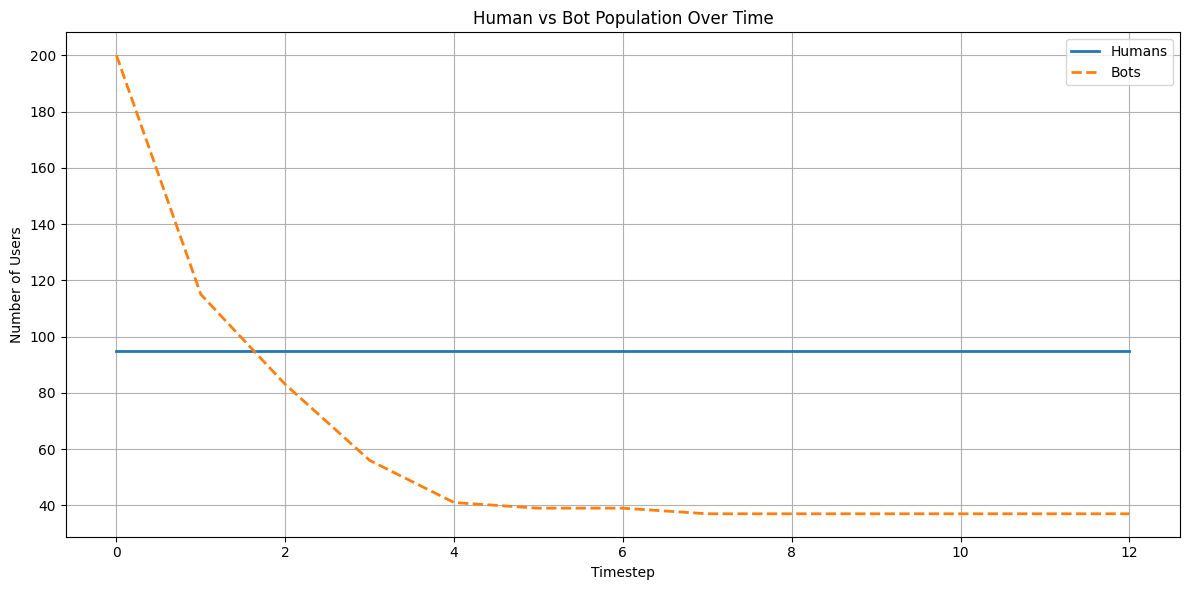

In [6]:
static_bot_counts = bot_counts

plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt

# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0

print("--- Starting Offline Training Simulator ---")
# base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

# update_human_bot_population()

# 1. Create the population for this episode
print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
active_users = []
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
random.shuffle(active_users)

human_count = sum(1 for u in active_users if not u.is_bot)
bot_count = sum(1 for u in active_users if u.is_bot)

while active_users:
    # ---- Population tracking per timestep ----
    # human_count = sum(1 for u in active_users if not u.is_bot)
    # bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

    next_active_users = []
    new_pending_experiences = {}

    for user in active_users:
        # 1. Get user's data and calculate current state s_t
        mouse_data = user.get_step_data()
        humanity_score = get_humanity_score(mouse_data)

        if user.is_bot and humanity_score is not None:
            humanity_score = humanity_score ** 4

        if humanity_score is None:
            # print(humanity_score, user.average_humanity_score, "handling")
            if user.average_humanity_score is None:
                humanity_score = 0.5
            else:
                humanity_score = user.average_humanity_score
        else:
            user.last_humanity_score = humanity_score
            if user.average_humanity_score is None:
                user.average_humanity_score = humanity_score
            else:
                user.average_humanity_score = (user.average_humanity_score * user.n_humanity_score + humanity_score) / (user.n_humanity_score + 1)
            user.n_humanity_score += 1

        # client_req_rate_per_min = 6 + random.randint(-2, 2)


        conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
        # print(user.is_bot, humanity_score)

        s_t = [
            humanity_score,
            user.average_humanity_score if user.average_humanity_score is not None else 0.5,
            user.captchas_solved,
            user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
            # server_req_rate_per_min,
            server_total_users
        ]

        # 2. Finalize the experience from step t-1
        if user.client_id in pending_experiences:
            prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
            s_prime = s_t  # The current state is the "next_state" for the previous action

            # Store the *completed* transition from t-1
            offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done)
            episode_reward += prev_r

        # 3. Check if user's session ended *naturally* (ran out of data)
        if user.done:
            continue  # User is done, no new action to take

        # 4. User is still active, take a new action (a_t)
        a_t = offline_rl_agent.select_action(s_t)

        # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
        r_t, done_t = calculate_reward(user, a_t)

        # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

        # 6. Store this new experience
        if done_t:
            # This is a terminal state (e.g., bot was killed).
            # We have the full experience now. Store it immediately.
            s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
            offline_rl_agent.remember(s_t, a_t, r_t, s_prime, done_t)
            episode_reward += r_t
            if user.is_bot:
                bot_count -= 1
        else:
            # This is a non-terminal state.
            # Store it as pending, waiting for s' from the next step.
            new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
            user.last_captcha_solved = a_t
            next_active_users.append(user)  # User continues

    # --- End of Step ---
    active_users = next_active_users
    pending_experiences = new_pending_experiences

    if not active_users:
        print(f"All users finished.")

print(f"Net reward: {episode_reward}")
print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
print(f"Confusion Matrix: {conf}")

--- Starting Offline Training Simulator ---
Creating population: 95 humans, 200 bots
All users finished.
Net reward: 9992.0
Normalized reward: 33.87
Confusion Matrix: {'human': {'predicted': {'human': 2084, 'bot': 386}}, 'bot': {'predicted': {'human': 591, 'bot': 828}}}


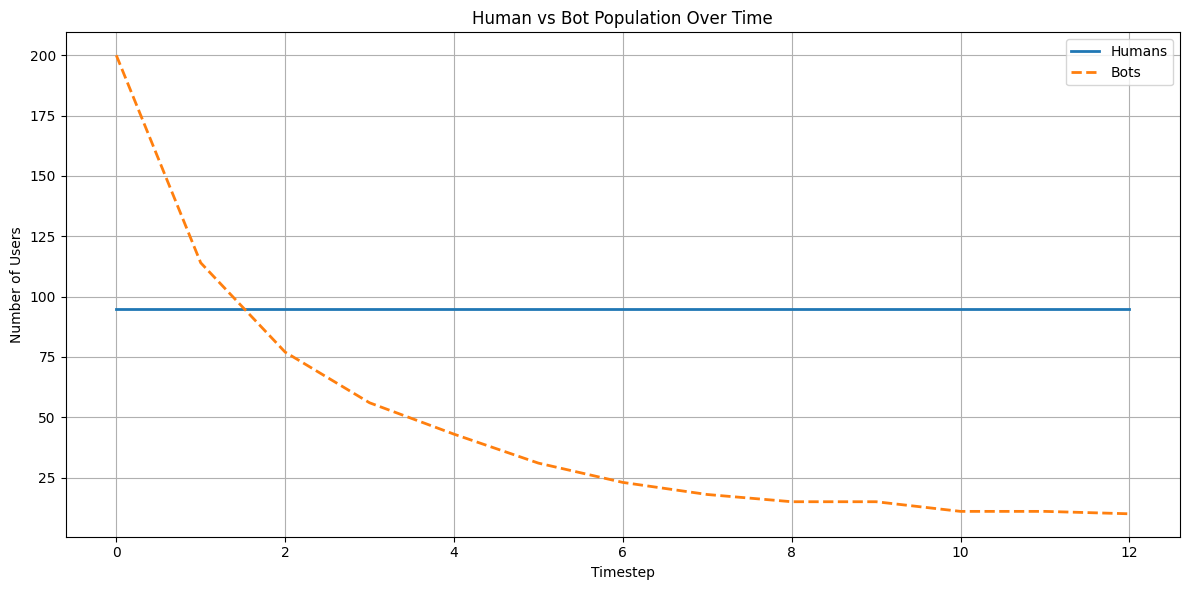

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

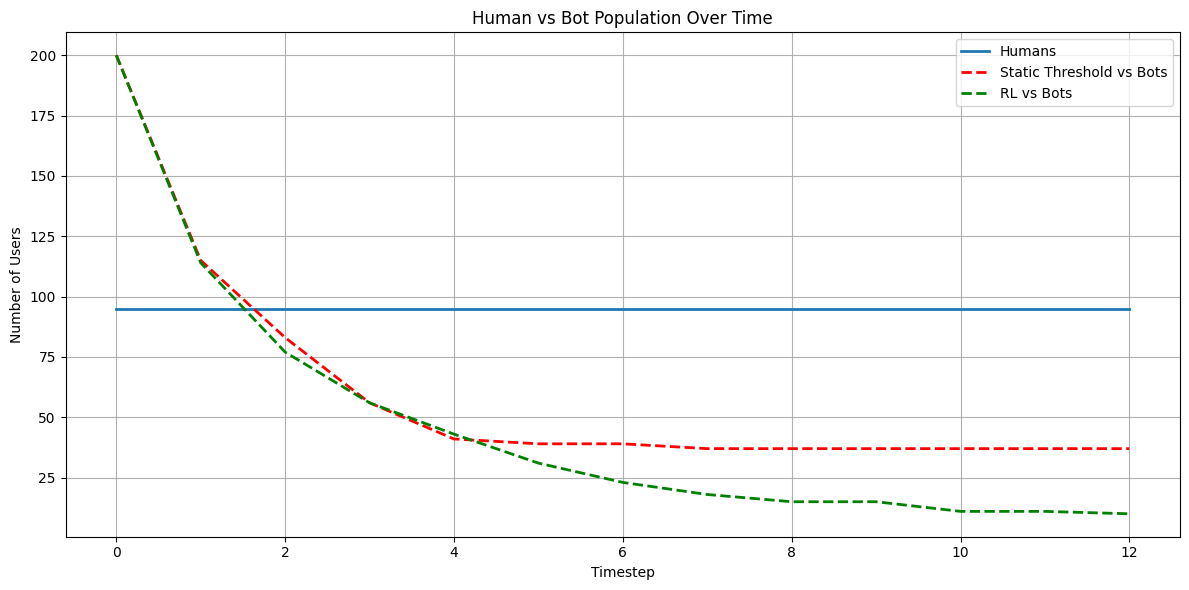

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, static_bot_counts,
         label="Static Threshold vs Bots",
         linestyle="--",
         linewidth=2,
         color="red")

plt.plot(timestep_counts, bot_counts,
         label="RL vs Bots",
         linestyle="--",
         linewidth=2,
         color="green")

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
class Account:
    def __init__(self, id, name):
        self.id = id
        self.name = name 
    def __del__(self):
        print(f"{self.__class__} destroyed")
        print(f"{self.__class__.__name__} destroyed")

a1 = Account(1, "a")
a2 = Account(2, "b")

del a1
del a2

<class '__main__.Account'> destroyed
Account destroyed
<class '__main__.Account'> destroyed
Account destroyed
